#  Sales Data Analysis using Python

---

##  Objective

The objective of this project is to analyze one year of retail sales data to uncover business trends, customer purchasing behavior, and product performance using Python.

This project demonstrates the complete data analysis workflow, including:

- Data Collection
- Data Cleaning
- Feature Engineering
- Exploratory Data Analysis (EDA)
- Data Visualization
- Business Insight Generation

The findings from this analysis can help businesses improve inventory management, marketing strategies, and decision-making.

#  Table of Contents

1. Import Required Libraries
2. Load and Combine Dataset
3. Dataset Overview
4. Data Cleaning
5. Feature Engineering
6. Investigation 1: Monthly Sales Analysis
7. Investigation 2: City-wise Sales Analysis
8. Investigation 3: Best Selling Products
9. Investigation 4: Sales by Hour
10. Investigation 5: Products Bought Together
11. Investigation 6: Correlation Analysis
12. Business Recommendations
13. Conclusion

#  Step 1: Import Required Libraries

Before performing any analysis, the required Python libraries are imported.

These libraries help with:

- Data manipulation (Pandas)
- Data visualization (Matplotlib & Seaborn)
- Combining multiple CSV files (Glob)

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
plt.style.use("ggplot")

#  Step 2: Load and Combine Sales Dataset

The sales data is distributed across twelve CSV files, with one file representing each month.

These files are combined into a single DataFrame to perform year-wide business analysis.

In [22]:
files = glob.glob("*.csv")
print("Number of files found:", len(files))
df = pd.concat([pd.read_csv(file) for file in files], ignore_index=True)
df.head()

Number of files found: 12


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,248151,AA Batteries (4-pack),4,3.84,09/17/19 14:44,"380 North St, Los Angeles, CA 90001"
1,248152,USB-C Charging Cable,2,11.95,09/29/19 10:19,"511 8th St, Austin, TX 73301"
2,248153,USB-C Charging Cable,1,11.95,09/16/19 17:48,"151 Johnson St, Los Angeles, CA 90001"
3,248154,27in FHD Monitor,1,149.99,09/27/19 07:52,"355 Hickory St, Seattle, WA 98101"
4,248155,USB-C Charging Cable,1,11.95,09/01/19 19:03,"125 5th St, Atlanta, GA 30301"


#  Step 3: Dataset Overview

Understanding the dataset is an important first step before analysis.

This includes:

- Number of rows and columns
- Data types
- Missing values
- Statistical summary

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186850 entries, 0 to 186849
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Order ID          186305 non-null  object
 1   Product           186305 non-null  object
 2   Quantity Ordered  186305 non-null  object
 3   Price Each        186305 non-null  object
 4   Order Date        186305 non-null  object
 5   Purchase Address  186305 non-null  object
dtypes: object(6)
memory usage: 8.6+ MB


In [24]:
df.shape

(186850, 6)

In [25]:
df.describe(include="all")

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
count,186305,186305,186305,186305,186305,186305
unique,178438,20,10,24,142396,140788
top,Order ID,USB-C Charging Cable,1,11.95,Order Date,Purchase Address
freq,355,21903,168552,21903,355,355


In [26]:
df.isnull().sum()

,0
Order ID,545
Product,545
Quantity Ordered,545
Price Each,545
Order Date,545
Purchase Address,545


###  Observation

The dataset contains sales records collected throughout the year.

Some missing values and incorrect data types are present, which must be addressed before performing analysis.

#  Step 4: Data Cleaning

Real-world datasets often contain:

- Missing values
- Incorrect rows
- Wrong data types

Cleaning the dataset improves data quality and ensures accurate analysis.

In [27]:
df = df.dropna()
df = df[df["Order Date"] != "Order Date"]
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,248151,AA Batteries (4-pack),4,3.84,09/17/19 14:44,"380 North St, Los Angeles, CA 90001"
1,248152,USB-C Charging Cable,2,11.95,09/29/19 10:19,"511 8th St, Austin, TX 73301"
2,248153,USB-C Charging Cable,1,11.95,09/16/19 17:48,"151 Johnson St, Los Angeles, CA 90001"
3,248154,27in FHD Monitor,1,149.99,09/27/19 07:52,"355 Hickory St, Seattle, WA 98101"
4,248155,USB-C Charging Cable,1,11.95,09/01/19 19:03,"125 5th St, Atlanta, GA 30301"


In [28]:
df["Quantity Ordered"] = pd.to_numeric(df["Quantity Ordered"])
df["Price Each"] = pd.to_numeric(df["Price Each"])
df.dtypes

,0
Order ID,object
Product,object
Quantity Ordered,int64
Price Each,float64
Order Date,object
Purchase Address,object


###  Observation

Missing values and invalid rows were successfully removed.

The numerical columns were converted to appropriate data types, making the dataset ready for further analysis.

#  Step 5: Feature Engineering

Feature engineering involves creating new columns from existing data.

New features help answer important business questions such as:

- Which month generated the highest revenue?
- Which city performed best?
- What time do customers shop the most?

In [30]:
df["Sales"] = df["Quantity Ordered"] * df["Price Each"]
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Month"] = df["Order Date"].dt.month
df["Hour"] = df["Order Date"].dt.hour
df["City"] = df["Purchase Address"].apply(lambda x: x.split(",")[1])
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Sales,Month,Hour,City
0,248151,AA Batteries (4-pack),4,3.84,2019-09-17 14:44:00,"380 North St, Los Angeles, CA 90001",15.36,9,14,Los Angeles
1,248152,USB-C Charging Cable,2,11.95,2019-09-29 10:19:00,"511 8th St, Austin, TX 73301",23.90,9,10,Austin
2,248153,USB-C Charging Cable,1,11.95,2019-09-16 17:48:00,"151 Johnson St, Los Angeles, CA 90001",11.95,9,17,Los Angeles
3,248154,27in FHD Monitor,1,149.99,2019-09-27 07:52:00,"355 Hickory St, Seattle, WA 98101",149.99,9,7,Seattle
4,248155,USB-C Charging Cable,1,11.95,2019-09-01 19:03:00,"125 5th St, Atlanta, GA 30301",11.95,9,19,Atlanta


###  Observation

Several new features were created to simplify business analysis.

The Sales column represents total revenue for each transaction, while Month, Hour, and City enable time-based and location-based analysis.

#  Investigation 1: Monthly Sales Analysis

##  Objective

The objective of this analysis is to determine which month generated the highest sales revenue.

Understanding monthly sales trends helps businesses:
- Identify peak sales seasons
- Improve inventory planning
- Design effective marketing campaigns
- Forecast future demand

Month
1     1822256.73
2     2202022.42
3     2807100.38
4     3390670.24
5     3152606.75
6     2577802.26
7     2647775.76
8     2244467.88
9     2097560.13
10    3736726.88
11    3199603.20
12    4613443.34
Name: Sales, dtype: float64


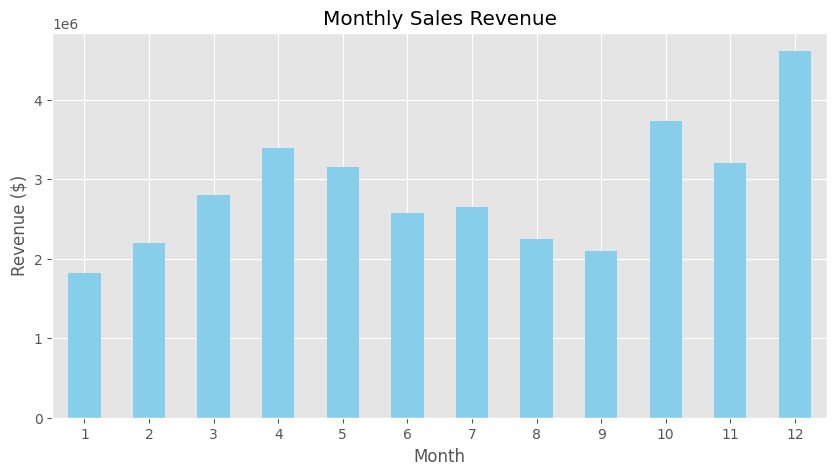

In [31]:
monthly_sales = df.groupby("Month")["Sales"].sum()
print(monthly_sales)
plt.figure(figsize=(10,5))
monthly_sales.plot(kind="bar", color="skyblue")
plt.title("Monthly Sales Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=0)
plt.show()

###  Observation

The monthly sales analysis shows that **December (Month 12)** generated the highest revenue, with total sales of approximately **$4.61 million**. This indicates a significant increase in customer purchases during the holiday season.

In contrast, **January (Month 1)** recorded the lowest sales revenue, with approximately **$1.82 million** in sales. Sales generally showed an upward trend throughout the year, with noticeable peaks in **April, October, November, and December**.

These findings suggest that seasonal events, festivals, and holiday shopping have a strong influence on customer purchasing behavior.

###  Business Insight

Based on the sales trend, the company should prepare for increased demand during the final quarter of the year, particularly in **October, November, and December**.

Recommended actions include:

- Increase inventory before the holiday season to avoid stock shortages.
- Launch promotional campaigns during high-demand months.
- Allocate additional staff and logistics support to handle increased order volumes.
- Use the sales trend for demand forecasting and inventory planning.

##  Key Insight

December was the highest revenue-generating month, recording approximately **$4.61 million** in sales. This indicates that customer demand significantly increased during the holiday season, making the final quarter of the year the most profitable period for the business.

#  Investigation 2: City-wise Sales Analysis

##  Objective

The objective of this analysis is to identify which cities generated the highest sales revenue.

Understanding city-wise performance helps businesses:
- Identify high-performing markets
- Allocate resources efficiently
- Plan region-specific marketing strategies

City
San Francisco    8262203.91
Los Angeles      5452570.80
New York City    4664317.43
Boston           3661642.01
Atlanta          2795498.58
Dallas           2767975.40
Seattle          2747755.48
Portland         2320490.61
Austin           1819581.75
Name: Sales, dtype: float64


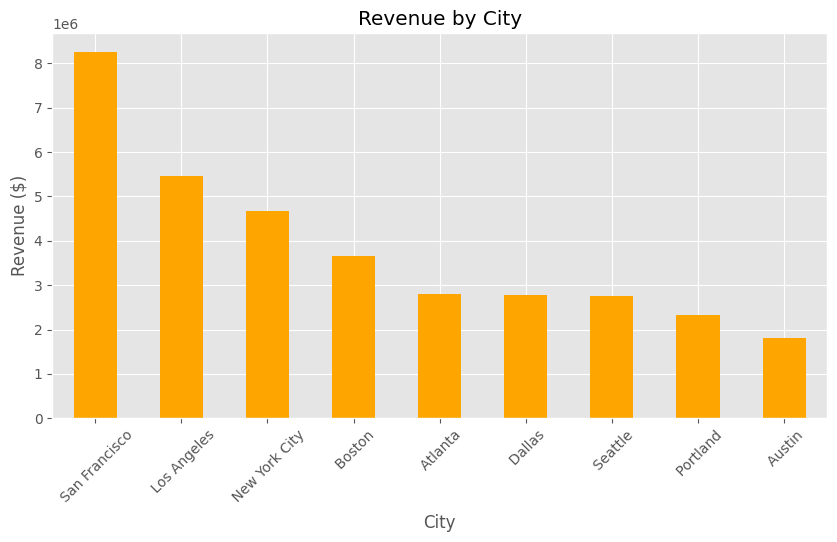

In [32]:
city_sales = df.groupby("City")["Sales"].sum().sort_values(ascending=False)
print(city_sales)
plt.figure(figsize=(10,5))
city_sales.plot(kind="bar", color="orange")
plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.show()

### Observation

The city-wise sales analysis reveals that San Francisco generated the highest revenue, with total sales of approximately $8.26 million. This was followed by Los Angeles ($5.45 million) and New York City ($4.66 million), making them the top three performing cities.

On the other hand, Austin recorded the lowest sales revenue, with approximately $1.82 million. The variation in sales across different cities indicates differences in customer demand, market size, and purchasing behavior.

Overall, metropolitan cities contributed significantly more to the company's total revenue than smaller cities.

###  Business Insight

The analysis suggests that the company should prioritize investment in high-performing cities such as **San Francisco**, **Los Angeles**, and **New York City**, where customer demand is the strongest.

Recommended actions include:

- Increase inventory levels in high-demand cities to prevent stock shortages.
- Expand marketing campaigns in top-performing regions to maximize revenue.
- Investigate the reasons for lower sales in cities such as **Austin** and **Portland** to identify opportunities for business growth.
- Use city-wise sales trends to optimize distribution and supply chain planning.

###  Key Finding

**San Francisco is the company's highest revenue-generating city, contributing more than $8.26 million in sales during the year.**

#  Investigation 3: Best Selling Products

##  Objective

The objective of this analysis is to identify the products with the highest sales volume.

This helps businesses:
- Understand customer demand
- Optimize inventory management
- Focus marketing efforts on popular products

Product
AAA Batteries (4-pack)        31017
AA Batteries (4-pack)         27635
USB-C Charging Cable          23975
Lightning Charging Cable      23217
Wired Headphones              20557
Apple Airpods Headphones      15661
Bose SoundSport Headphones    13457
27in FHD Monitor               7550
iPhone                         6849
27in 4K Gaming Monitor         6244
34in Ultrawide Monitor         6199
Google Phone                   5532
Flatscreen TV                  4819
Macbook Pro Laptop             4728
ThinkPad Laptop                4130
20in Monitor                   4129
Vareebadd Phone                2068
LG Washing Machine              666
LG Dryer                        646
Name: Quantity Ordered, dtype: int64


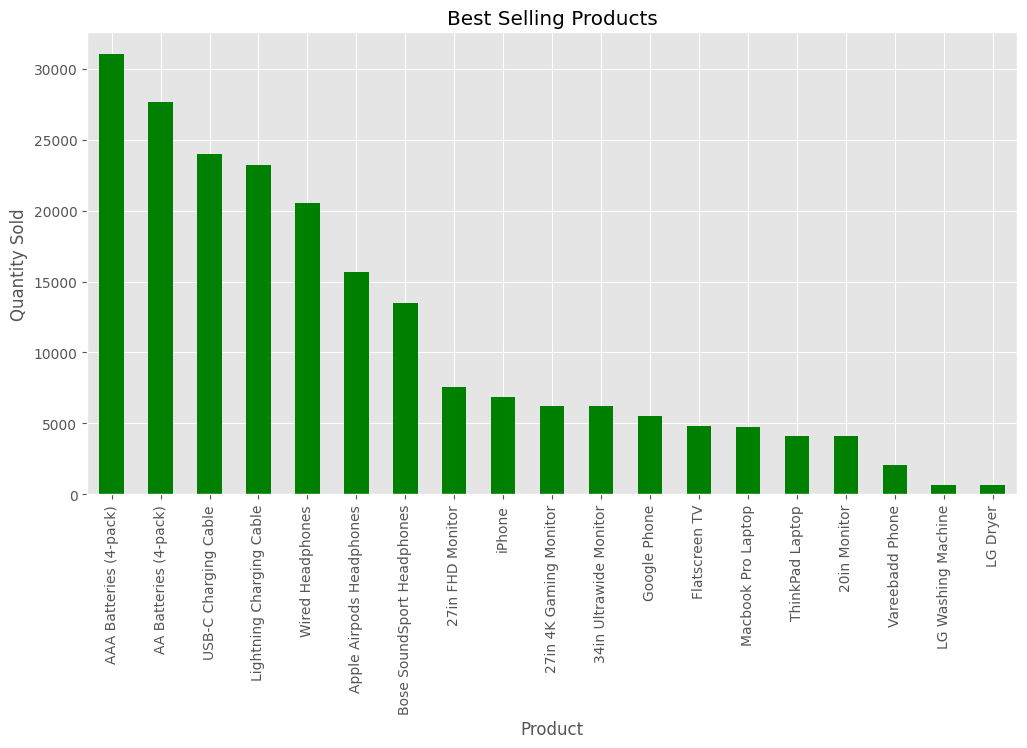

In [33]:
product_sales = df.groupby("Product")["Quantity Ordered"].sum().sort_values(ascending=False)
print(product_sales)
plt.figure(figsize=(12,6))
product_sales.plot(kind="bar", color="green")
plt.title("Best Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=90)
plt.show()

##  Observation

The product-wise sales analysis shows that **AAA Batteries (4-pack)** was the best-selling product, with **31,017 units sold**. This was followed by **AA Batteries (4-pack)** with **27,635 units**, and **USB-C Charging Cable** with **23,956 units**.

Products such as **Lightning Charging Cable**, **Wired Headphones**, and **Apple AirPods Headphones** also recorded strong sales, indicating a high demand for electronic accessories.

In contrast, products like **LG Washing Machine** and **LG Dryer** had the lowest sales volumes, with only **666** and **646 units sold**, respectively.

##  Business Insight

The analysis indicates that low-cost electronic accessories are purchased much more frequently than high-value home appliances.

Based on these findings, the company should:

- Maintain sufficient inventory of high-demand products such as batteries, charging cables, and headphones.
- Offer bundle deals on frequently purchased accessories to increase overall sales.
- Develop targeted marketing strategies to improve the sales of low-performing products like washing machines and dryers.
- Use sales trends to optimize inventory management and reduce stock shortages.

##  Key Finding

AAA Batteries (4-pack) emerged as the highest-selling product, while LG Washing Machine and LG Dryer recorded the lowest sales. This suggests that affordable everyday electronic accessories contribute significantly more to sales volume than expensive household appliances.

#  Investigation 4: Sales by Hour

##  Objective

The objective of this analysis is to determine the hours of the day when customers make the most purchases.

Understanding customer purchasing behavior helps businesses:
- Schedule promotions effectively
- Optimize staffing during peak hours
- Improve customer service

Hour
0      713721.27
1      460866.88
2      234851.44
3      145757.89
4      162661.01
5      230679.82
6      448113.00
7      744854.12
8     1192348.97
9     1639030.58
10    1944286.77
11    2300610.24
12    2316821.34
13    2155389.80
14    2083672.73
15    1941549.60
16    1904601.31
17    2129361.61
18    2219348.30
19    2412938.54
20    2281716.24
21    2042000.86
22    1607549.21
23    1179304.44
Name: Sales, dtype: float64


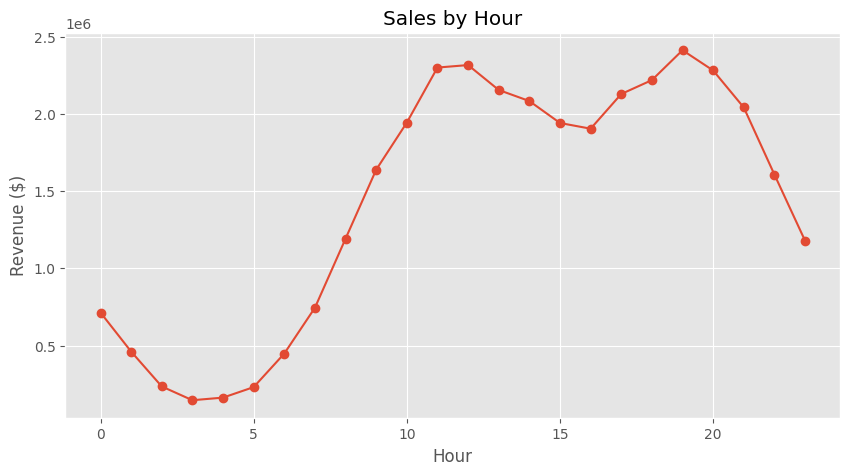

In [34]:
hour_sales = df.groupby("Hour")["Sales"].sum()
print(hour_sales)
plt.figure(figsize=(10,5))
hour_sales.plot(marker="o")
plt.title("Sales by Hour")
plt.xlabel("Hour")
plt.ylabel("Revenue ($)")
plt.grid(True)
plt.show()

##  Observation

The hourly sales analysis shows that customer purchases gradually increase during the morning hours and reach their highest levels in the evening.

The highest sales revenue was recorded at **7:00 PM (Hour 19)**, with approximately **$2.42 million** in sales. Sales remained consistently high between **10:00 AM and 8:00 PM**, indicating that this is the busiest shopping period of the day.

In contrast, the lowest sales occurred during the early morning hours (around **3:00 AM to 5:00 AM**), when customer activity was minimal.

##  Business Insight

The analysis indicates that customer activity is highest during the afternoon and evening hours.

Based on these findings, the company should:

- Schedule promotional offers and flash sales during peak shopping hours (10 AM–8 PM).
- Ensure adequate staffing and customer support during high-demand periods.
- Optimize warehouse and delivery operations to handle increased order volumes in the evening.
- Perform website maintenance during early morning hours when customer traffic is at its lowest.

##  Key Finding

The highest sales revenue was generated at **7:00 PM**, indicating that evening hours are the most profitable period for the business. Understanding customer purchasing patterns can help improve marketing strategies, inventory planning, and operational efficiency.

#  Investigation 5: Products Frequently Bought Together

##  Objective

The objective of this analysis is to identify products that customers frequently purchase together.

Understanding purchasing patterns helps businesses:

- Design bundle offers
- Increase cross-selling opportunities
- Improve product recommendations
- Optimize product placement

In [35]:
from itertools import combinations
from collections import Counter
# Keep only orders with multiple products
multi_orders = df[df["Order ID"].duplicated(keep=False)]
# Group products by Order ID
multi_orders = multi_orders.groupby("Order ID")["Product"].apply(list)
# Count product pairs
count = Counter()
for products in multi_orders:
    count.update(Counter(combinations(sorted(products), 2)))
print(count.most_common(10))

[(('Lightning Charging Cable', 'iPhone'), 1015), (('Google Phone', 'USB-C Charging Cable'), 999), (('Wired Headphones', 'iPhone'), 462), (('Google Phone', 'Wired Headphones'), 423), (('Apple Airpods Headphones', 'iPhone'), 373), (('USB-C Charging Cable', 'Vareebadd Phone'), 368), (('Bose SoundSport Headphones', 'Google Phone'), 228), (('USB-C Charging Cable', 'Wired Headphones'), 205), (('Vareebadd Phone', 'Wired Headphones'), 149), (('Lightning Charging Cable', 'Wired Headphones'), 129)]


##  Observation

The analysis identified the top product pairs that customers frequently purchased together. These combinations represent complementary products that are commonly bought within the same order.

Such purchasing patterns indicate customer preferences and provide opportunities for increasing sales through bundle offers and recommendation systems.

##  Business Insight

The company can increase revenue by recommending frequently purchased product pairs during checkout.

Suggested strategies include:

- Create bundle discounts for commonly purchased products.
- Display related products on the product page.
- Recommend complementary accessories during checkout.
- Use purchase history to improve personalized recommendations.

##  Key Insight

Frequently purchased product combinations reveal customer buying patterns and provide valuable opportunities for cross-selling and bundle promotions. Recommending complementary products during checkout can improve customer experience while increasing overall sales revenue.

#  Investigation 6: Correlation Analysis

##  Objective

The objective of this analysis is to identify relationships between numerical variables in the dataset.

Correlation analysis helps businesses understand how different variables influence one another and supports better decision-making.

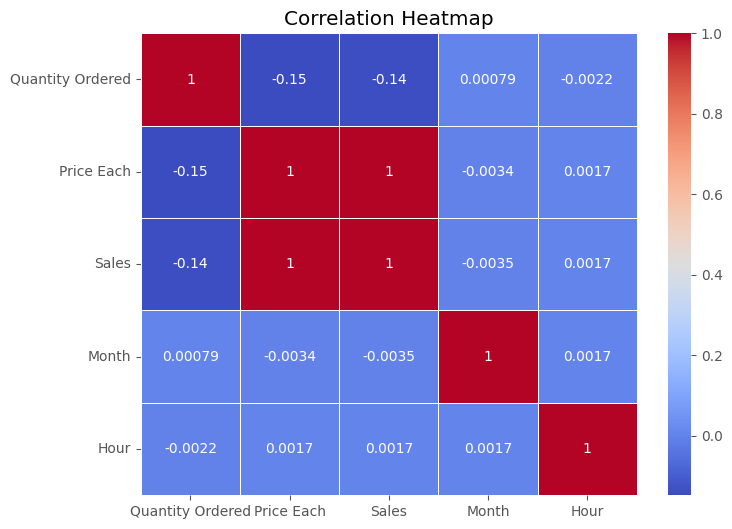

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

##  Observation

The correlation heatmap illustrates the relationships among numerical variables in the dataset.

Positive correlation values indicate that two variables increase together, while negative values indicate an inverse relationship.

The heatmap helps identify variables that may influence sales performance and supports data-driven decision-making.

##  Business Insight

Correlation analysis enables businesses to understand the factors that influence sales and customer behavior.

The insights gained from this analysis can be used for:

- Improving forecasting models.
- Identifying important business metrics.
- Supporting predictive analytics.
- Making informed strategic decisions based on data relationships.

##  Key Insight

The correlation analysis provides a clear overview of the relationships between numerical variables in the dataset. Understanding these relationships helps identify important business metrics, supports predictive analytics, and enables more informed, data-driven decision-making.

#  Business Recommendations

Based on the analysis, the following recommendations can help improve business performance:

1. **Prepare for Seasonal Demand**
   - Increase inventory before October, November, and December to meet higher customer demand.
   - Launch festive offers and promotional campaigns during peak sales periods.

2. **Focus on High-Performing Cities**
   - Invest more in cities such as **San Francisco**, **Los Angeles**, and **New York City**, which generate the highest revenue.
   - Analyze lower-performing cities to identify opportunities for growth.

3. **Maintain Inventory of Popular Products**
   - Ensure adequate stock of high-demand products such as batteries, charging cables, and headphones.
   - Introduce bundle offers for frequently purchased accessories.

4. **Promote Frequently Purchased Product Combinations**
   - Recommend complementary products during checkout.
   - Offer discounts on commonly purchased product pairs to increase average order value.

5. **Optimize Operations During Peak Hours**
   - Schedule marketing campaigns and flash sales during afternoon and evening hours.
   - Increase staffing and delivery capacity during peak shopping periods.

6. **Leverage Data Analytics**
   - Continuously monitor sales trends and customer behavior.
   - Use predictive analytics to improve inventory management and demand forecasting.

#  Conclusion

This project involved performing a comprehensive Exploratory Data Analysis (EDA) on a retail sales dataset to identify patterns, trends, and actionable business insights.

The analysis revealed that:

- December generated the highest monthly sales revenue, indicating strong seasonal demand.
- San Francisco was the highest revenue-generating city.
- AAA Batteries (4-pack) emerged as the best-selling product.
- Customer purchases peaked during the evening hours, especially around 7 PM.
- Frequently purchased product combinations provide opportunities for cross-selling and bundle promotions.
- Correlation analysis helped understand relationships among numerical variables, supporting data-driven decision-making.

Through data cleaning, feature engineering, visualization, and business analysis, this project demonstrates how raw sales data can be transformed into meaningful insights that support strategic business decisions.

Overall, this project strengthened practical skills in **Python, Pandas, Matplotlib, Seaborn, Exploratory Data Analysis (EDA), Feature Engineering, and Business Analytics**, while highlighting the importance of data-driven decision-making in real-world business scenarios.